,session_depth,cache-s,query-cache-estimate-s,query-cache-s
0,1,0.379430,0.379139,0.377473
1,2,0.308386,0.378660,0.321708
2,3,0.532741,0.549138,0.532040
3,4,0.710503,0.701021,0.735862
4,5,0.654879,0.562923,0.591251
5,6,1.000000,1.000000,1.000000
6,7,0.346298,0.348502,0.348502


,sequence_depth,cache-s,query-cache-estimate-s,query-cache-s
0,0,0.021217,0.021217,0.021217
1,1,0.377778,0.377778,0.381111
2,2,0.675591,0.675630,0.676051
3,3,0.364133,0.360118,0.361972
4,4,0.266602,0.272656,0.267513
5,5,0.673059,0.673516,0.673059
6,6,0.286291,0.297701,0.270716
7,7,0.242076,0.243812,0.250222
8,8,0.128239,0.194436,0.129178
9,9,0.604063,0.491287,0.584764


,session_depth,cache-s,query-cache-estimate-s,query-cache-s
0,1,1.387798,3.233404,3.374874
1,2,1.542440,1.064146,0.894454
2,3,1.736387,1.135852,1.400906
3,4,3.819791,7.335133,0.893832
4,5,2.062448,1.716905,1.933119
5,6,0.000000,0.000000,0.000000
6,7,0.560800,0.919724,0.883457


,sequence_depth,cache-s,query-cache-estimate-s,query-cache-s
0,0,0.000000,0.000000,0.000000
1,1,0.000000,0.000000,0.000000
2,2,0.544314,0.188793,0.111879
3,3,0.600990,0.790638,0.559981
4,4,3.106807,2.467186,2.883929
5,5,0.603714,0.281943,0.233905
6,6,1.046293,0.939950,0.998007
7,7,2.026657,0.981480,1.025291
8,8,0.163971,0.123610,0.162171
9,9,3.679696,3.142532,3.280800


Saved: ./session_depth_metrics.pdf


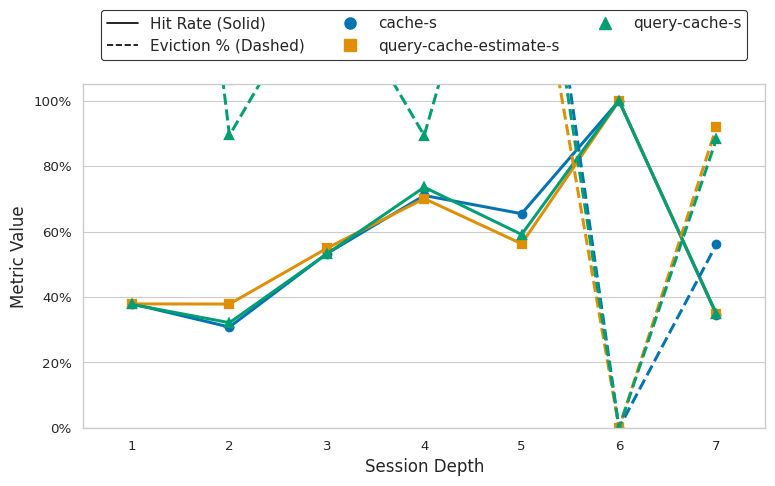

Saved: ./sequence_depth_metrics.pdf


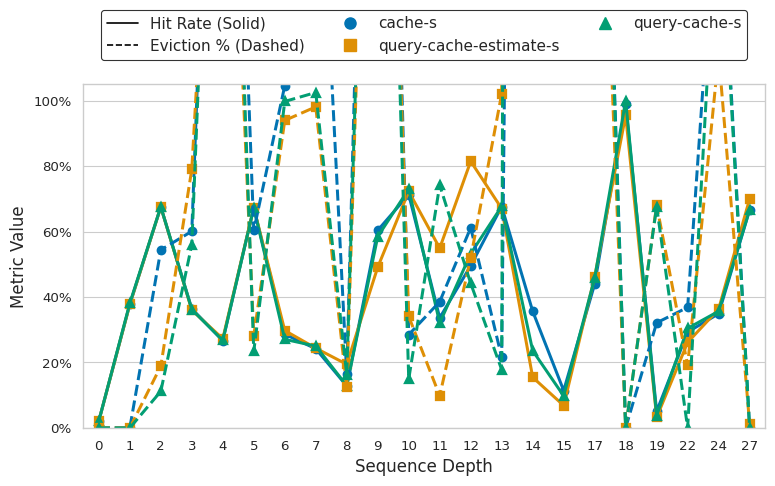

In [2]:
import os
from typing import List, Tuple, Dict, Any
import pandas as pd
import matplotlib.ticker as ticker
from rich.jupyter import display


def extract_cache_stats(entry: Dict[str, Any]) -> Tuple[int, int]:
    """Extracts hit and total counts from the cache state JSON string."""
    cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

    if not cache_str:
        return 0, 0

    try:
        cache_stats = json.loads(cache_str)
        hits = cache_stats.get("hits", 0)
        total = hits + cache_stats.get("misses", 0)
        return hits, total
    except json.JSONDecodeError:
        return 0, 0

def extract_eviction_percentage(entry: Dict[str, Any]) -> float:
    """Extracts the eviction percentage from the cache state JSON string."""
    cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

    if not cache_str:
        return np.nan

    try:
        cache_stats = json.loads(cache_str)
        if "evictionPercentage" in cache_stats:
            return float(cache_stats["evictionPercentage"])
        return np.nan
    except (json.JSONDecodeError, ValueError, TypeError):
        return np.nan

def apply_min_support(df: pd.DataFrame, depth_col: str, value_col: str, min_support: int) -> pd.DataFrame:
    """
    Aggregates data by depth and algorithm, filtering out depths
    where the number of observations falls below min_support.
    """
    if df.empty:
        return pd.DataFrame()

    # Aggregate to compute both mean and observation count
    agg_df = df.groupby(['algorithm', depth_col])[value_col].agg(['mean', 'count']).reset_index()

    # Filter out depths lacking sufficient support
    valid_df = agg_df[agg_df['count'] >= min_support]

    if valid_df.empty:
        return pd.DataFrame()

    # Pivot for output
    pivot_df = valid_df.pivot(index=depth_col, columns='algorithm', values='mean').reset_index()
    pivot_df.columns.name = None

    return pivot_df

def calculate_depth_hit_rates(filenames: List[str], min_support: int = 1) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Parses result files to calculate average hit rates, filtering by minimum support."""
    records = []

    for path in sorted(filenames):
        algo_label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")

        with open(path, 'r') as file:
            data = json.load(file)

        prev_session_id = None
        session_depth = 0

        for entry in data:
            sequence_depth_str = entry.get("id")
            if sequence_depth_str is None:
                continue

            sequence_depth = int(sequence_depth_str)

            seq_element = entry.get("sequenceElement", {})
            session_info = seq_element.get("session", {})
            current_session_id = session_info.get("sessionId")

            if current_session_id is None:
                continue

            if current_session_id != prev_session_id:
                session_depth = 1
            else:
                session_depth += 1

            hits, total = extract_cache_stats(entry)

            if total > 0:
                records.append({
                    'algorithm': algo_label,
                    'sequence_depth': sequence_depth,
                    'session_depth': session_depth,
                    'hit_rate': hits / total
                })

            prev_session_id = current_session_id

    df = pd.DataFrame(records)
    session_pivot = apply_min_support(df, 'session_depth', 'hit_rate', min_support)
    sequence_pivot = apply_min_support(df, 'sequence_depth', 'hit_rate', min_support)

    return session_pivot, sequence_pivot

def calculate_depth_eviction_rates(filenames: List[str], min_support: int = 1) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Parses result files to calculate average cache eviction percentages, filtering by minimum support."""
    records = []

    for path in sorted(filenames):
        algo_label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")

        with open(path, 'r') as file:
            data = json.load(file)

        prev_session_id = None
        session_depth = 0

        for entry in data:
            sequence_depth_str = entry.get("id")
            if sequence_depth_str is None:
                continue

            sequence_depth = int(sequence_depth_str)

            seq_element = entry.get("sequenceElement", {})
            session_info = seq_element.get("session", {})
            current_session_id = session_info.get("sessionId")

            if current_session_id is None:
                continue

            if current_session_id != prev_session_id:
                session_depth = 1
            else:
                session_depth += 1

            eviction_pct = extract_eviction_percentage(entry)

            if not np.isnan(eviction_pct):
                records.append({
                    'algorithm': algo_label,
                    'sequence_depth': sequence_depth,
                    'session_depth': session_depth,
                    'eviction_percentage': eviction_pct
                })

            prev_session_id = current_session_id

    df = pd.DataFrame(records)
    session_pivot = apply_min_support(df, 'session_depth', 'eviction_percentage', min_support)
    sequence_pivot = apply_min_support(df, 'sequence_depth', 'eviction_percentage', min_support)

    return session_pivot, sequence_pivot

def plot_combined_depth_metrics(hit_df: pd.DataFrame, evict_df: pd.DataFrame, depth_col: str, save_name: str, save_path: str = "."):
    """
    Merges hit rate and eviction dataframes into a long format and generates
    a point plot mapping hit rates to solid lines and eviction percentages to dashed lines.
    """
    if hit_df.empty or evict_df.empty:
        print(f"Insufficient data for plotting {depth_col}.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Convert wide data back to long data for Seaborn
    hit_melted = hit_df.melt(id_vars=[depth_col], var_name='algorithm', value_name='Value')
    hit_melted['Metric'] = 'Hit Rate'

    evict_melted = evict_df.melt(id_vars=[depth_col], var_name='algorithm', value_name='Value')
    evict_melted['Metric'] = 'Eviction Percentage'

    # Combine datasets
    combined_df = pd.concat([hit_melted, evict_melted], ignore_index=True)
    combined_df['Value'] = pd.to_numeric(combined_df['Value'], errors='coerce')
    combined_df = combined_df.dropna(subset=['Value'])

    # Apply target styling constraints
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    algorithm_order = sorted(combined_df['algorithm'].unique().tolist())
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))
    style_markers = ["o", "s", "^", "D", "v", "P", "X"]

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    # Hit Rate (Solid lines)
    sns.pointplot(
        data=combined_df[combined_df['Metric'] == 'Hit Rate'],
        x=depth_col, y="Value",
        hue="algorithm", hue_order=algorithm_order,
        palette="colorblind",
        markers=style_markers[:len(algorithm_order)],
        linestyles=["-"] * len(algorithm_order),
        ax=ax, errorbar=None, legend=False
    )

    # Eviction Percentage (Dashed lines)
    sns.pointplot(
        data=combined_df[combined_df['Metric'] == 'Eviction Percentage'],
        x=depth_col, y="Value",
        hue="algorithm", hue_order=algorithm_order,
        palette="colorblind",
        markers=style_markers[:len(algorithm_order)],
        linestyles=["--"] * len(algorithm_order),
        ax=ax, errorbar=None, legend=False
    )

    # Formatting axes
    x_label = "Sequence Depth" if depth_col == "sequence_depth" else "Session Depth"
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Metric Value", fontsize=12)

    # Format Y-axis as percentages
    ax.set_ylim(bottom=0, top=1.05)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:.0%}'))

    # Build Custom Legend
    custom_handles = [
        mlines.Line2D([], [], color='black', linestyle='-', label='Hit Rate (Solid)'),
        mlines.Line2D([], [], color='black', linestyle='--', label='Eviction % (Dashed)')
    ]
    custom_labels = ['Hit Rate (Solid)', 'Eviction % (Dashed)']

    for i, alg in enumerate(algorithm_order):
        c = colors[i]
        m = style_markers[i % len(style_markers)]
        custom_handles.append(mlines.Line2D([], [], color=c, marker=m, linestyle='', markersize=8))
        custom_labels.append(alg)

    # Place legend horizontally above the plot
    plt.legend(handles=custom_handles, labels=custom_labels,
               loc='lower center', bbox_to_anchor=(0.5, 1.05),
               ncol=3, frameon=True, edgecolor='black', fontsize=11)

    plt.tight_layout()

    save_target = os.path.join(save_path, save_name)
    plt.savefig(save_target, bbox_inches='tight')
    print(f"Saved: {save_target}")
    plt.show()

if __name__ == "__main__":
    pattern = os.path.join("..", "data", "query-results-raw-*.json")
    files = glob.glob(pattern)

    if not files:
        print("Error: No data files found matching the pattern.")
        raise ValueError("No matching data files found.")
    # Execution Pipeline
    session_depth_df, sequence_depth_df = calculate_depth_hit_rates(files, min_support=20)
    session_depth_df_evict, sequence_depth_df_evict = calculate_depth_eviction_rates(files, min_support=20)

    # Display DataFrames
    display(session_depth_df)
    display(sequence_depth_df)
    display(session_depth_df_evict)
    display(sequence_depth_df_evict)

    # Generate Plots
    plot_combined_depth_metrics(
        session_depth_df, session_depth_df_evict,
        depth_col="session_depth", save_name="session_depth_metrics.pdf"
    )
    plot_combined_depth_metrics(
        sequence_depth_df, sequence_depth_df_evict,
        depth_col="sequence_depth", save_name="sequence_depth_metrics.pdf"
    )

In [3]:
from typing import List, Tuple, Dict, Any
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# [Keep extract_cache_stats from the previous code]
def extract_cache_stats(entry: Dict[str, Any]) -> Tuple[int, int]:
    cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")
    if not cache_str: return 0, 0
    try:
        cache_stats = json.loads(cache_str)
        hits = cache_stats.get("hits", 0)
        total = hits + cache_stats.get("misses", 0)
        return hits, total
    except json.JSONDecodeError:
        return 0, 0

def apply_min_support(df: pd.DataFrame, depth_col: str, value_col: str, min_support: int) -> pd.DataFrame:
    if df.empty: return pd.DataFrame()
    agg_df = df.groupby(['algorithm', depth_col])[value_col].agg(['mean', 'count']).reset_index()
    valid_df = agg_df[agg_df['count'] >= min_support]
    if valid_df.empty: return pd.DataFrame()
    pivot_df = valid_df.pivot(index=depth_col, columns='algorithm', values='mean').reset_index()
    pivot_df.columns.name = None
    return pivot_df

def calculate_normalized_depth_hit_rates(filenames: List[str], min_support: int = 1) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Calculates hit rate DELTAS (actual - template baseline) to isolate
    the effect of sequence/session depth from template variance.
    """
    records = []

    for path in sorted(filenames):
        algo_label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")

        with open(path, 'r') as file:
            data = json.load(file)

        prev_session_id = None
        session_depth = 0

        for entry in data:
            sequence_depth_str = entry.get("id")
            if sequence_depth_str is None:
                continue

            sequence_depth = int(sequence_depth_str)

            seq_element = entry.get("sequenceElement", {})
            session_info = seq_element.get("session", {})
            current_session_id = session_info.get("sessionId")

            # EXTRACT TEMPLATE HERE
            template = seq_element.get("template")

            if current_session_id is None or not template:
                continue

            if current_session_id != prev_session_id:
                session_depth = 1
            else:
                session_depth += 1

            hits, total = extract_cache_stats(entry)

            if total > 0:
                records.append({
                    'algorithm': algo_label,
                    'template': template,
                    'sequence_depth': sequence_depth,
                    'session_depth': session_depth,
                    'hit_rate': hits / total
                })

            prev_session_id = current_session_id

    df = pd.DataFrame(records)
    if df.empty:
        return pd.DataFrame(), pd.DataFrame()

    # 1. Calculate the baseline hit rate for each template per algorithm
    baselines = df.groupby(['algorithm', 'template'])['hit_rate'].mean().reset_index()
    baselines.rename(columns={'hit_rate': 'template_baseline'}, inplace=True)

    # 2. Merge baselines back into the main DataFrame
    df = df.merge(baselines, on=['algorithm', 'template'])

    # 3. Calculate the absolute delta
    df['hit_rate_delta'] = df['hit_rate'] - df['template_baseline']

    # 4. Apply minimum support and group by the delta instead of raw hit rate
    session_pivot = apply_min_support(df, 'session_depth', 'hit_rate_delta', min_support)
    sequence_pivot = apply_min_support(df, 'sequence_depth', 'hit_rate_delta', min_support)

    return session_pivot, sequence_pivot

def plot_normalized_metrics(df: pd.DataFrame, depth_col: str, save_name: str, save_path: str = "."):
    """Plots the isolated hit rate deltas."""
    if df.empty:
        print(f"Insufficient data for plotting {depth_col}.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    melted_df = df.melt(id_vars=[depth_col], var_name='algorithm', value_name='Delta')
    melted_df['Delta'] = pd.to_numeric(melted_df['Delta'], errors='coerce')
    melted_df = melted_df.dropna(subset=['Delta'])

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    algorithm_order = sorted(melted_df['algorithm'].unique().tolist())
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))
    style_markers = ["o", "s", "^", "D", "v", "P", "X"]

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    # Plot the isolated deltas
    sns.pointplot(
        data=melted_df,
        x=depth_col, y="Delta",
        hue="algorithm", hue_order=algorithm_order,
        palette="colorblind",
        markers=style_markers[:len(algorithm_order)],
        linestyles=["-"] * len(algorithm_order),
        ax=ax, errorbar=None
    )

    # Add a bold line at 0 (the baseline)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=0, label="Template Baseline")

    x_label = "Sequence Depth" if depth_col == "sequence_depth" else "Session Depth"
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Hit Rate Delta (vs Template Baseline)", fontsize=12)

    # Custom Legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title="Algorithm", loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    save_target = os.path.join(save_path, save_name)
    plt.savefig(save_target, bbox_inches='tight')
    print(f"Saved: {save_target}")
    plt.show()

# Execution
# session_delta_df, sequence_delta_df = calculate_normalized_depth_hit_rates(files, min_support=40)
# plot_normalized_metrics(sequence_delta_df, 'sequence_depth', 'normalized_sequence_depth.pdf')

In [25]:
from itertools import combinations
import glob
import json
import os
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
from scipy.stats import kruskal, f_oneway, mannwhitneyu


def test_switch_significance(df: pd.DataFrame, metric: str = 'abs_delta') -> pd.DataFrame:
    """
    Performs statistical testing on the switch_type deltas per algorithm.
    """
    results = []

    # Run the test independently for each algorithm
    for algo, group_df in df.groupby('algorithm'):

        # Extract the metric arrays for each switch type
        groups = [
            subset[metric].dropna().values
            for name, subset in group_df.groupby('switch_type')
        ]

        # Require at least 2 groups to perform a comparison
        if len(groups) < 2:
            continue

        # Non-parametric: Kruskal-Wallis
        kw_stat, kw_p = kruskal(*groups)

        # Parametric: One-Way ANOVA
        anova_stat, anova_p = f_oneway(*groups)

        results.append({
            'algorithm': algo,
            'kruskal_stat': kw_stat,
            'kruskal_p_value': kw_p,
            'anova_stat': anova_stat,
            'anova_p_value': anova_p
        })

    return pd.DataFrame(results)

def post_hoc_pairwise_tests(df: pd.DataFrame, metric: str = 'abs_delta', alpha: float = 0.05) -> pd.DataFrame:
    """
    Performs pairwise Mann-Whitney U tests for each algorithm's switch types.
    Applies Bonferroni correction and determines the direction of significant differences.
    """
    results = []

    for algo, group_df in df.groupby('algorithm'):
        # Get distinct switch types (e.g., 'new_session', 'within_session', 'existing_session')
        switch_types = group_df['switch_type'].dropna().unique()

        # Generate all unique pairs
        pairs = list(combinations(switch_types, 2))
        num_comparisons = len(pairs)

        # Bonferroni corrected alpha threshold
        adjusted_alpha = alpha / num_comparisons if num_comparisons > 0 else alpha

        for group1, group2 in pairs:
            data1 = group_df[group_df['switch_type'] == group1][metric].dropna()
            data2 = group_df[group_df['switch_type'] == group2][metric].dropna()

            if len(data1) == 0 or len(data2) == 0:
                continue

            # Two-sided Mann-Whitney U test (non-parametric)
            stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')

            # Determine direction using median central tendency
            median1 = data1.median()
            median2 = data2.median()
            diff = median1 - median2

            # Determine human-readable outcome
            if p_val < adjusted_alpha:
                if diff > 0:
                    direction = f"{group1} > {group2}"
                elif diff < 0:
                    direction = f"{group1} < {group2}"
                else:
                    direction = "Significant (Medians Equal, Dist. Differs)"
            else:
                direction = "No significant difference"

            results.append({
                'algorithm': algo,
                'group_1': group1,
                'group_2': group2,
                'median_diff': diff,
                'p_value': p_val,
                'alpha_adjusted': adjusted_alpha,
                'is_significant': p_val < adjusted_alpha,
                'direction': direction
            })

    return pd.DataFrame(results)

def extract_cache_stats(entry: Dict[str, Any]) -> Tuple[int, int]:
    """Extracts hit and total counts from the cache state JSON string."""
    cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

    if not cache_str:
        return 0, 0

    try:
        cache_stats = json.loads(cache_str)
        hits = cache_stats.get("hits", 0)
        total = hits + cache_stats.get("misses", 0)
        return hits, total
    except json.JSONDecodeError:
        return 0, 0


def calculate_switch_effect(filenames: List[str]) -> pd.DataFrame:
    """
    Parses result files, normalizes hit rates against arithmetic template baselines,
    and aggregates absolute and relative hit rate deltas (means and standard deviations)
    of session states.
    """
    records = []

    for path in sorted(filenames):
        algo_label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")

        with open(path, 'r') as file:
            data = json.load(file)

        seen_sessions = set()
        prev_session_id = None

        for entry in data:
            seq_element = entry.get("sequenceElement", {})
            session_info = seq_element.get("session", {})
            current_session_id = session_info.get("sessionId")

            if not current_session_id:
                continue

            template = seq_element.get("template")
            hits, total = extract_cache_stats(entry)

            if total == 0 or not template:
                seen_sessions.add(current_session_id)
                prev_session_id = current_session_id
                continue

            if prev_session_id is None or (
                    current_session_id not in seen_sessions and current_session_id != prev_session_id):
                switch_type = "new_session"
            elif current_session_id == prev_session_id:
                switch_type = "within_session"
            else:
                switch_type = "existing_session"

            records.append({
                'algorithm': algo_label,
                'template': template,
                'switch_type': switch_type,
                'hit_rate': hits / total
            })

            seen_sessions.add(current_session_id)
            prev_session_id = current_session_id

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)

    # 1. Calculate baseline using arithmetic mean
    baselines = df.groupby(['algorithm', 'template'])['hit_rate'].mean().reset_index()
    baselines.rename(columns={'hit_rate': 'template_baseline'}, inplace=True)

    # 2. Merge baselines back to individual records
    df = df.merge(baselines, on=['algorithm', 'template'])

    # 3. Calculate individual record deltas
    df['abs_delta'] = df['hit_rate'] - df['template_baseline']
    df['pct_delta'] = np.where(
        df['template_baseline'] == 0,
        np.nan,
        (df['abs_delta'] / df['template_baseline']) * 100
    )
    # display(test_switch_significance(df))
    # display(post_hoc_pairwise_tests(df, metric='abs_delta'))

    # 4. Aggregate rates by algorithm and switch type (Mean and Std)
    effect_df = df.groupby(['algorithm', 'switch_type']).agg(
        abs_delta_mean=('abs_delta', 'mean'),
        abs_delta_std=('abs_delta', 'std'),
        pct_delta_mean=('pct_delta', 'mean'),
        pct_delta_std=('pct_delta', 'std')
    ).reset_index()

    # 5. Pivot for presentation
    pivot_df = effect_df.pivot(
        index='algorithm',
        columns='switch_type',
        values=['abs_delta_mean', 'abs_delta_std', 'pct_delta_mean', 'pct_delta_std']
    )

    # Flatten the MultiIndex columns
    new_cols = []
    for val, switch in pivot_df.columns:
        if val == 'abs_delta_mean':
            new_cols.append(switch)
        elif val == 'abs_delta_std':
            new_cols.append(f"{switch}_std")
        elif val == 'pct_delta_mean':
            new_cols.append(f"{switch}_pct")
        elif val == 'pct_delta_std':
            new_cols.append(f"{switch}_pct_std")

    pivot_df.columns = new_cols
    pivot_df = pivot_df.reset_index()

    # Enforce column ordering, injecting NaNs for missing switch types
    base_columns = ['new_session', 'existing_session', 'within_session']
    col_order = ['algorithm']

    for base in base_columns:
        std_col = f"{base}_std"
        pct_col = f"{base}_pct"
        pct_std_col = f"{base}_pct_std"

        for c in [base, std_col, pct_col, pct_std_col]:
            if c not in pivot_df.columns:
                pivot_df[c] = np.nan
            col_order.append(c)

    # Filter to the final structured order
    pivot_df = pivot_df[[c for c in col_order if c in pivot_df.columns]]

    return pivot_df

if __name__ == "__main__":
    # pattern = os.path.join("..", "data", "data-random-init", "query-results-raw-cache-random-init-*.json")
    # files = glob.glob(pattern)
    #
    # if not files:
    #     print("Error: No data files found matching the pattern.")
    #     raise ValueError("No matching data files found.")
    # calculate_switch_effect(files)
    # switch_effect_random_init = calculate_switch_effect(files)
    # display(switch_effect_random_init)

    files_original = glob.glob(os.path.join("..", "data", "query-results-raw-*.json"))
    switch_effect = calculate_switch_effect(files_original)
    display(switch_effect)


# output_df = calculate_switch_effect(files)
# output_df.to_csv(float_format='%.3f')

,algorithm,new_session,new_session_std,new_session_pct,new_session_pct_std,existing_session,existing_session_std,existing_session_pct,existing_session_pct_std,within_session,within_session_std,within_session_pct,within_session_pct_std
0,cache-random-init-l,0.021889,0.265393,3.605045,94.406062,-0.150703,0.235836,-39.897901,67.609455,0.114446,0.301242,30.327370,100.617914
1,cache-random-init-m,-0.011847,0.209510,3.437432,148.656903,-0.140465,0.178944,-45.517948,72.265875,0.107088,0.306815,34.608019,125.215788
2,cache-random-init-s,-0.094289,0.070995,-61.951557,33.482359,-0.116267,0.152113,-46.491814,83.723912,0.089730,0.308707,36.193143,223.349220


,algorithm,new_session,new_session_std,new_session_pct,new_session_pct_std,existing_session,existing_session_std,existing_session_pct,existing_session_pct_std,within_session,within_session_std,within_session_pct,within_session_pct_std
0,cache-l,-0.065599,0.320183,-6.632400,71.101128,-0.013696,0.337987,-3.749899,70.163641,0.011273,0.321124,2.940341,64.165000
1,cache-m,-0.056492,0.248767,-19.007723,69.123027,-0.030931,0.343355,-9.976349,111.625024,0.024277,0.308700,7.840159,86.507874
2,cache-s,-0.070885,0.239405,-26.443532,87.486093,-0.021268,0.330213,0.354292,148.077932,0.017106,0.296975,0.071488,118.247294
3,query-cache-estimate-l,-0.053117,0.323323,-8.332869,74.053933,-0.014745,0.339041,-3.727233,73.301587,0.011924,0.317774,2.948198,66.629027
4,query-cache-estimate-m,0.028221,0.318065,4.578013,92.251910,-0.000269,0.336938,-3.399295,98.533208,-0.000160,0.297241,2.528779,84.601623
5,query-cache-estimate-s,-0.043950,0.237344,3.141147,135.579710,-0.012746,0.330228,0.175167,151.101210,0.010270,0.276253,-0.173884,123.315220
6,query-cache-l,-0.026489,0.326562,-2.869185,69.622457,-0.003197,0.341614,-1.802558,68.673442,0.002776,0.325315,1.409291,62.748212
7,query-cache-m,-0.086832,0.249753,-28.414126,72.775740,-0.021434,0.350187,-6.634494,100.391165,0.017457,0.319888,5.423241,83.397478
8,query-cache-s,-0.033353,0.236524,1.648882,122.165766,-0.014856,0.343753,2.270992,134.262060,0.011740,0.290034,-1.750160,102.886988
